# Name : Bilal Hussain Shah

# ID: 922688

# Title: Product Quality Control (Bottle Products) Using Vision-Based Anomaly Detection



# =============================================================
# 1 Google Drive Mount & Dataset Extraction
# =============================================================

In [1]:

from google.colab import drive # Import Google Colab utility to mount Google Drive
import tarfile # Import tarfile to extract compressed dataset archives
import os # Import os for file and directory handling

drive.mount('/content/drive') # Mount Google Drive at /content/drive, This allows access to datasets stored in Drive
dataset_path = "/content/drive/My Drive/ColabNotebooks/bottle.tar.xz" # Path to the compressed MVTec bottle dataset (.tar.xz)
extract_path = "/content/mvtec" # Directory where dataset will be extracted
os.makedirs(extract_path, exist_ok=True) # Create extraction directory if it does not exist


with tarfile.open(dataset_path, "r:xz") as tar: # Open the tar.xz archive in read mode
    tar.extractall(path=extract_path)     # Extract all dataset files into extract_path

print("Dataset extracted successfully.")




Mounted at /content/drive


/tmp/ipython-input-4019274032.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)     # Extract all dataset files into extract_path


Dataset extracted successfully.




# =============================================================
# 2️ Dataset Preparation
# =============================================================

In [2]:
import glob # glob is used to retrieve file paths matching a pattern
from PIL import Image # PIL Image is used for image loading


# Directory containing normal (defect-free) training images
# Used for UNSUPERVISED training
train_dir = "/content/mvtec/bottle/train/good"

# Dictionary mapping defect type to its directory
# Used for test set (normal + defective)
test_dirs = {
    "good": "/content/mvtec/bottle/test/good",
    "broken_large": "/content/mvtec/bottle/test/broken_large",
    "broken_small": "/content/mvtec/bottle/test/broken_small",
    "contamination": "/content/mvtec/bottle/test/contamination"
}

# Load all normal training image paths
normal_imgs = sorted(glob.glob(os.path.join(train_dir, "*.png")))

# Lists to store test image paths and corresponding labels
test_imgs_paths, test_labels = [], []

# Loop over each defect category
for key, path in test_dirs.items():
    # Load all image paths in the category
    imgs = sorted(glob.glob(os.path.join(path, "*.png")))
    test_imgs_paths.extend(imgs)

    # Label assignment: 0 = normal, 1 = defective
    label = 0 if key == "good" else 1
    test_labels.extend([label]*len(imgs))

# Print dataset statistics
print(f"Normal train images: {len(normal_imgs)}")
print(f"Total test images: {len(test_imgs_paths)} (labels 0: {test_labels.count(0)}, 1: {test_labels.count(1)})")

Normal train images: 209
Total test images: 83 (labels 0: 20, 1: 63)




# =============================================================
# 3️ Transformations
# =============================================================

In [3]:
# torchvision.transforms provides image preprocessing utilities
import torchvision.transforms as transforms

# Transformations for GAN Autoencoder
# Only resizing and tensor conversion (no normalization)
ae_transform = transforms.Compose([
    transforms.Resize((128,128)),   # Resize image
    transforms.ToTensor(),          # Convert to PyTorch tensor
])

# Transformations for CNN
# Includes data augmentation for robustness
cnn_transform = transforms.Compose([
    transforms.Resize((128,128)),           # Resize image
    transforms.RandomHorizontalFlip(),       # Random horizontal flip
    transforms.RandomRotation(15),           # Small random rotation
    transforms.ToTensor(),                   # Convert to tensor
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # Normalize RGB channels
])



# =============================================================
# 4️ PyTorch Dataset Classes
# =============================================================

In [4]:
# Import PyTorch core modules
import torch
from torch.utils.data import Dataset, DataLoader

class NormalImageDataset(Dataset):
    """Dataset class for loading ONLY normal images ( PCA training)"""

    def __init__(self, image_paths, transform=None):
        self.paths = image_paths          # Image file paths
        self.transform = transform        # Optional transformations

    def __len__(self):
        # Returns number of images
        return len(self.paths)

    def __getitem__(self, idx):
        # Load image and convert to RGB
        img = Image.open(self.paths[idx]).convert("RGB")

        # Apply transformation if provided
        if self.transform:
            img = self.transform(img)
        return img

class TestImageDataset(Dataset):
    """Dataset class for testing AE, PCA, and CNN"""

    def __init__(self, image_paths, labels, transform=None):
        self.paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Load image
        img = Image.open(self.paths[idx]).convert("RGB")

        # Get corresponding label
        label = self.labels[idx]

        # Apply transformation
        if self.transform:
            img = self.transform(img)

        # Return image, label, and file path
        return img, label, self.paths[idx]



# =============================================================
# 5️ Device Setup
# =============================================================

In [5]:
# Select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu




# =============================================================
# 6️ GAN Autoencoder Definition
# =============================================================

In [6]:
# Neural network layers
import torch.nn as nn
import torch.nn.functional as F

class GANAutoencoder(nn.Module):
    """
    Convolutional Autoencoder used for UNSUPERVISED anomaly detection.
    Trained only on normal images.
    """
    def __init__(self):
        super(GANAutoencoder, self).__init__()

        # Encoder: compress image into latent representation
        # First Layer:
        # Input channels = 3 → the input image has 3 channels (RGB).
        # Output channels = 16 → produces 16 feature maps.
        # Kernel size = 3 → 3×3 convolutional filter.
        # Stride = 2 → moves the filter 2 pixels at a time → downsamples the image by ~half.
        # Padding = 1 → adds 1 pixel of zero-padding on each side → maintains approximate feature map size.
        # ReLU → introduces non-linearity, improves training stability,
        #         and encourages sparse, meaningful feature representations.
        #         ReLU keeps only positive activations:
        #         - Strong features pass through
        #         - Weak or noisy signals are suppressed
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU()
        )

        # Decoder: reconstruct image from latent representation
        # First Decoder Layer:
        # Input channels = 64 → receives compressed latent feature maps from the encoder.
        # Output channels = 32 → reduces feature depth while increasing spatial resolution.
        # Kernel size = 3 → 3×3 transposed convolution filter.
        # Stride = 2 → upsamples the feature map by approximately 2×.
        # Padding = 1 → helps maintain alignment with the encoder’s downsampling.
        # Output padding = 1 → ensures exact spatial size matching during upsampling.
        # ReLU → introduces non-linearity and allows the network to learn complex reconstructions.
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),

            # Second Decoder Layer:
            # Input channels = 32 → intermediate reconstructed feature maps.
            # Output channels = 16 → further reduces feature depth while continuing upsampling.
            # Kernel size = 3 → 3×3 transposed convolution.
            # Stride = 2 → upsamples spatial dimensions again.
            # Padding = 1 and output padding = 1 → preserve symmetry with encoder layers.
            # ReLU → maintains non-linearity and enables gradual reconstruction refinement.
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),

            # Final Decoder Layer:
            # Input channels = 16 → refined feature maps.
            # Output channels = 3 → reconstructs the original RGB image.
            # Kernel size = 3 → 3×3 transposed convolution.
            # Stride = 2 → final upsampling to original image resolution.
            # Padding = 1 and output padding = 1 → ensures correct output image size.
            # Sigmoid → squashes pixel values to [0, 1], suitable for normalized image data.
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        # Encode input image into latent space
        x = self.encoder(x)

        # Decode latent representation back into image
        x = self.decoder(x)
        return x

class Discriminator(nn.Module):
    """
    CNN Discriminator used in the GAN Autoencoder.
    Its role is to distinguish between:
    - Real images (original normal samples)
    - Fake images (reconstructed outputs from the autoencoder)

    The discriminator provides adversarial feedback that encourages
    the autoencoder to produce more realistic reconstructions.
    """
    def __init__(self):
        super(Discriminator, self).__init__()

        # Discriminator Network:
        # A deep convolutional classifier that gradually downsamples
        # the input image and learns high-level visual features.
        self.net = nn.Sequential(

            # First Convolutional Layer:
            # Input channels = 3 → RGB input image.
            # Output channels = 32 → extracts 32 low-level feature maps
            #                        (edges, textures, color gradients).
            # Kernel size = 4 → 4×4 convolutional filter captures local patterns.
            # Stride = 2 → downsamples the image by half (spatial reduction).
            # Padding = 1 → preserves spatial alignment during convolution.
            # LeakyReLU (0.2) → allows small gradients for negative values,
            #                   preventing "dead neurons" and improving GAN stability.
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # Second Convolutional Layer:
            # Input channels = 32 → receives feature maps from previous layer.
            # Output channels = 64 → learns more complex patterns and structures.
            # Kernel size = 4 → captures larger spatial dependencies.
            # Stride = 2 → further reduces spatial resolution.
            # Padding = 1 → maintains proper feature map alignment.
            # LeakyReLU → continues stable gradient flow during adversarial training.
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # Third Convolutional Layer:
            # Input channels = 64 → mid-level features.
            # Output channels = 128 → high-level semantic representations
            #                         (object parts, structural patterns).
            # Kernel size = 4 → captures even broader spatial context.
            # Stride = 2 → aggressive downsampling for compact representation.
            # Padding = 1 → consistent spatial scaling.
            # LeakyReLU → improves robustness and training stability.
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2), # LeakyReLU is used in the discriminator to avoid dead neurons and maintain stable gradient flow during adversarial training, which is critical for GAN convergence.”

            # Flatten Layer:
            # Converts 3D feature maps into a 1D feature vector.
            # For a 128×128 input image, after three downsampling steps:
            # Feature map size ≈ [128, 16, 16]
            nn.Flatten(),

            # Fully Connected Layer:
            # Input features = 128 * 16 * 16 → flattened feature vector.
            # Output features = 1 → single scalar value representing
            #                     "realness score" of the input image.
            nn.Linear(128 * 16 * 16, 1),

            # Sigmoid Activation:
            # Maps output to the range [0, 1].
            # Interpretation:
            # - Value close to 1 → image is likely real
            # - Value close to 0 → image is likely fake (reconstructed)
            nn.Sigmoid()
        )

    def forward(self, x):
        # Forward pass through the discriminator network
        # Returns a probability score indicating whether
        # the input image is real or reconstructed.
        return self.net(x)




# =============================================================
# 7️ PCA Preparation
# =============================================================

In [7]:
# Import numpy and PCA
import numpy as np
from sklearn.decomposition import PCA

def load_flattened_images(paths, img_size=(128,128)):
    """
    Load images, convert to grayscale, normalize, and flatten.
    Used for PCA-based anomaly detection.
    """
    data = []
    for p in paths:
        img = Image.open(p).convert("L").resize(img_size)
# Image.open(p) → opens image file.
# convert("L") → converts to grayscale (1 channel).
# PCA works on 1D vectors, so a single-channel image is simpler and enough for anomaly detection.
# resize(img_size) → resizes to uniform dimensions (128×128).
        arr = np.array(img).astype(np.float32)/255.0
# Converts Python Imaging Library (PIL) image to NumPy array.
# astype(np.float32) → ensures values are float (0–1) instead of integers (0–255).
# Dividing by 255.0 → normalizes pixel values to [0,1].
        data.append(arr.flatten())
# flatten() → converts 2D 128×128 image into 1D vector of length 16,384 (128×128).
# PCA requires 2D array: samples × features, so flattening is necessary.
    return np.array(data)

# Load flattened normal images
normal_data = load_flattened_images(normal_imgs) # 2D NumPy array of shape (num_normal_images, 16384)

# Fit PCA only on normal data (unsupervised learning)
pca = PCA(n_components=100)
# Reduce dimensionality from 16,384 → 100.
# These 100 principal components capture most variance in the normal images.
# fit(normal_data) → learns principal components only from normal images.
# Important: PCA is unsupervised, so no labels are used here.
# This model captures the "normal subspace."
pca.fit(normal_data)
print("PCA fitted on normal data")


# Training: Fit PCA on normal images.
# Testing: Project new images onto PCA components and reconstruct them.
# Reconstruction error:
# error = || original−reconstructed||^2
#
# High reconstruction error → likely anomalous.
# Low reconstruction error → likely normal.


PCA fitted on normal data




# =============================================================
# 8️ CNN Classifier
# =============================================================

In [8]:
class SimpleCNN(nn.Module):
    """
    Supervised CNN classifier for defect detection.
    This network takes an RGB image as input and outputs
    a probability indicating whether a defect is present.
    """

    def __init__(self):
        # Initialize the parent class (nn.Module)
        super(SimpleCNN, self).__init__()

        # First convolutional layer:
        # - Input channels = 3 (RGB image)
        # - Output channels = 16 (number of learned feature maps)
        # - Kernel size = 3x3
        # - default stride = 1
        # - Padding = 1 (keeps spatial size unchanged)
        # Input shape  : [B, 3, 128, 128]
        # Output shape : [B, 16, 128, 128]
        # Learns low-level features such as edges, corners, and textures
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)

        # Second convolutional layer:
        # - Input channels = 16
        # - Output channels = 32
        # - Kernel size = 3x3
        # - Padding = 1 (keeps spatial size unchanged)
        # Input shape  : [B, 16, 64, 64]  (after pooling)
        # Output shape : [B, 32, 64, 64]
        # Learns mid-level features such as shapes, cracks, and contours
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        # Third convolutional layer:
        # - Input channels = 32
        # - Output channels = 64
        # - Kernel size = 3x3
        # - Padding = 1 (keeps spatial size unchanged)
        # Input shape  : [B, 32, 32, 32]  (after pooling)
        # Output shape : [B, 64, 32, 32]
        # Learns higher-level and more abstract defect features
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        # Max pooling layer:
        # - Kernel size = 2x2
        # - Stride = 2
        # Reduces spatial dimensions by half (downsampling)
        # Helps reduce computation and makes features more robust
        self.pool = nn.MaxPool2d(2, 2)

        # First fully connected (dense) layer:
        # - Input features = 64 * 16 * 16 = 16384
        #   (from final convolution output after pooling)
        # - Output features = 128
        # Compresses high-dimensional convolutional features
        # into a compact 128-dimensional representation
        self.fc1 = nn.Linear(64 * 16 * 16, 128)

        # Final fully connected layer:
        # - Input features = 128
        # - Output features = 1
        # Produces a single logit representing defect presence
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # Apply first convolution → ReLU activation → Max pooling
        # Extracts low-level features and downsamples the image
        # Conv1
# Takes RGB image
# Applies 16 different 3×3 filters
# Each filter detects something simple:
# edges
# corners
# color gradients
# Shape change:
# [1, 3, 128, 128] → [1, 16, 128, 128]
# ReLU
# Removes negative values
# Keeps strong signals
# Max Pooling (2×2)
# Keeps the strongest feature in each 2×2 block
# Reduces spatial size by half
# Final shape after step 1:
# [1, 16, 64, 64]
        x = self.pool(F.relu(self.conv1(x)))

        # Apply second convolution → ReLU activation → Max pooling
        # Extracts mid-level features and further downsamples
        x = self.pool(F.relu(self.conv2(x)))

        # Apply third convolution → ReLU activation → Max pooling
        # Extracts high-level features and reduces spatial size
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the feature maps into a 1D vector
        # Shape changes from [B, 64, 16, 16] → [B, 16384]
        # -1 tells PyTorch to automatically infer the batch size
        x = x.view(-1, 64 * 16 * 16)

        # Apply first fully connected layer with ReLU activation
        # Learns global relationships between extracted features
        # Compresses 16,384 features → 128 features
        # Learns global relationships [1, 16384] → [1, 128]
        x = F.relu(self.fc1(x))

        # Apply final fully connected layer followed by sigmoid
        # Sigmoid converts output to a probability in range [0, 1]
        # Suitable for binary classification (defect / no defect)
        x = torch.sigmoid(self.fc2(x))

        # Return the final prediction probability
        return x




# =============================================================
# 9️ DataLoaders
# =============================================================

In [9]:
batch_size = 16

# Dataset for CNN training
train_dataset_ae = NormalImageDataset(normal_imgs, transform=cnn_transform)
train_loader_ae = DataLoader(train_dataset_ae, batch_size=batch_size, shuffle=True)

# Test dataset for all models
test_dataset = TestImageDataset(test_imgs_paths, test_labels, transform=ae_transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)



# =============================================================
# 10️ Training GAN Autoencoder
# =============================================================

In [10]:
# Initialize Models

# Autoencoder (Generator):
# Learns to reconstruct normal images and fool the discriminator
ae_model = GANAutoencoder().to(device)

# Discriminator:
# Learns to distinguish real images from reconstructed (fake) images
disc_model = Discriminator().to(device)

# Optimizers

# Adam optimizer for the autoencoder
# Learning rate is kept moderate to avoid overpowering the discriminator
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=0.0005)

# Adam optimizer for the discriminator
# Same learning rate as AE ensures balanced adversarial training
disc_optimizer = torch.optim.Adam(disc_model.parameters(), lr=0.0005)

# Loss Functions

# Reconstruction loss:
# Measures pixel-wise difference between input and reconstructed image
# Encourages accurate reconstruction of normal patterns
recon_loss_fn = nn.MSELoss()

# MSE loss ensures the autoencoder accurately reconstructs normal images and provides the reconstruction error used for anomaly detection.
# BCELoss enables adversarial learning, encouraging the autoencoder to generate reconstructions that are indistinguishable from real images.

# Adversarial loss:
# Binary Cross Entropy loss for real vs fake classification
# Used by both discriminator and autoencoder (generator)
adv_loss_fn = nn.BCELoss()

# Training Parameters

# Number of training epochs
ae_epochs = 20

# Training Loop

for epoch in range(ae_epochs):

    # Set both models to training mode
    # (important for layers like batch normalization or dropout if present)
    ae_model.train()
    disc_model.train()

    # Track total losses for the epoch
    total_ae_loss = 0
    total_disc_loss = 0

    # Iterate over batches of normal training images
    for imgs in train_loader_ae:

        # Move input images to GPU/CPU
        imgs = imgs.to(device)

        # Get batch size (used for label creation)
        batch_size = imgs.size(0)


        # Label Smoothing


        # Real labels are set to 0.9 instead of 1.0
        # This prevents the discriminator from becoming overconfident
        real_labels = torch.full((batch_size, 1), 0.9).to(device)

        # Fake labels are set to 0.1 instead of 0.0
        # Improves GAN stability and gradient flow
        fake_labels = torch.full((batch_size, 1), 0.1).to(device)


        #  Train Discriminator

        # Clear old gradients from discriminator
        disc_optimizer.zero_grad()

        # ---- Discriminator on Real Images ----

        # Pass real images through discriminator
        real_preds = disc_model(imgs)

        # Compute loss: real images should be classified as "real"
        real_loss = adv_loss_fn(real_preds, real_labels)

        # ---- Discriminator on Fake Images ----

        # Generate reconstructed images using autoencoder
        # detach() prevents gradients from flowing back to the autoencoder
        fake_imgs = ae_model(imgs).detach()

        # Pass reconstructed images through discriminator
        fake_preds = disc_model(fake_imgs)

        # Compute loss: reconstructed images should be classified as "fake"
        fake_loss = adv_loss_fn(fake_preds, fake_labels)

        # Total discriminator loss is the average of real and fake losses
        disc_loss = (real_loss + fake_loss) / 2

        # Backpropagate discriminator loss
        disc_loss.backward()

        # Update discriminator weights
        disc_optimizer.step()


        #  Train Autoencoder (Generator)


        # Clear old gradients from autoencoder
        ae_optimizer.zero_grad()

        # Generate reconstructed images from input
        recon_imgs = ae_model(imgs)

        # ---- Reconstruction Loss ----

        # Compute pixel-wise reconstruction error
        # Encourages faithful reconstruction of normal images
        recon_loss = recon_loss_fn(recon_imgs, imgs)

        # ---- Adversarial Loss ----

        # Pass reconstructed images through discriminator
        adv_preds = disc_model(recon_imgs)

        # Autoencoder tries to fool discriminator
        # Reconstructed images are encouraged to be classified as "real"
        adv_loss = adv_loss_fn(adv_preds, real_labels)

        # ---- Total Autoencoder Loss ----

        # Combine reconstruction loss and adversarial loss
        # Adversarial loss is weighted to avoid overpowering reconstruction
        ae_loss = recon_loss + 0.01 * adv_loss

        # Backpropagate autoencoder loss
        ae_loss.backward()

        # Update autoencoder weights
        ae_optimizer.step()


        # Accumulate Batch Losses


        total_ae_loss += ae_loss.item()
        total_disc_loss += disc_loss.item()


    # Epoch Summary


    # Print average losses per epoch
    # AE Loss → reconstruction + adversarial quality
    # D Loss → discriminator's real/fake classification performance
    print(
        f"Epoch [{epoch+1}/{ae_epochs}] | "
        f"AE Loss: {total_ae_loss/len(train_loader_ae):.6f} | "
        f"D Loss: {total_disc_loss/len(train_loader_ae):.6f}"
    )


Epoch [1/20] | AE Loss: 0.810876 | D Loss: 0.394455
Epoch [2/20] | AE Loss: 0.781744 | D Loss: 0.330090
Epoch [3/20] | AE Loss: 0.627032 | D Loss: 0.326083
Epoch [4/20] | AE Loss: 0.382332 | D Loss: 0.325678
Epoch [5/20] | AE Loss: 0.310400 | D Loss: 0.326797
Epoch [6/20] | AE Loss: 0.292064 | D Loss: 0.326877
Epoch [7/20] | AE Loss: 0.271873 | D Loss: 0.326702
Epoch [8/20] | AE Loss: 0.265102 | D Loss: 0.326334
Epoch [9/20] | AE Loss: 0.261430 | D Loss: 0.325743
Epoch [10/20] | AE Loss: 0.262183 | D Loss: 0.325464
Epoch [11/20] | AE Loss: 0.255735 | D Loss: 0.325545
Epoch [12/20] | AE Loss: 0.258147 | D Loss: 0.325498
Epoch [13/20] | AE Loss: 0.257478 | D Loss: 0.325320
Epoch [14/20] | AE Loss: 0.253994 | D Loss: 0.325307
Epoch [15/20] | AE Loss: 0.247664 | D Loss: 0.325426
Epoch [16/20] | AE Loss: 0.252576 | D Loss: 0.325253
Epoch [17/20] | AE Loss: 0.243350 | D Loss: 0.325226
Epoch [18/20] | AE Loss: 0.249430 | D Loss: 0.325202
Epoch [19/20] | AE Loss: 0.248405 | D Loss: 0.325184
Ep



# =============================================================
# 11️ Training CNN Classifier
# =============================================================

In [21]:


#  to select defective images for training

# Initialized an empty list to store paths of defective images
defective_train_imgs = []

# Defined a small subset size to avoid using all images in the test set
# e.g., we take 30 images per defect type
subset_size = 30

# Loop over the types of defects we want to include
for key in ["broken_large", "broken_small", "contamination"]:
    # Get all PNG image paths for this defect type
    imgs = sorted(glob.glob(os.path.join(test_dirs[key], "*.png")))
    # Took only the first 'subset_size' images and added them to the list
    defective_train_imgs.extend(imgs[:subset_size])

#  Created labels for defective images

# Assigned label '1' to all defective images
# 1 = defective, 0 = normal
defective_train_labels = [1] * len(defective_train_imgs)

#  Combined defective and normal images

# Combined normal images with defective images for CNN training
cnn_train_imgs = normal_imgs + defective_train_imgs

# Created corresponding labels:
# - Normal images = 0
# - Defective images = 1
cnn_train_labels = [0] * len(normal_imgs) + defective_train_labels

#  Shuffle the dataset

from sklearn.utils import shuffle

# Shuffle images and labels together to randomize training order
# 'random_state=42' ensures reproducibility
cnn_train_imgs, cnn_train_labels = shuffle(cnn_train_imgs, cnn_train_labels, random_state=42)

#  Create Dataset and DataLoader

# 'TestImageDataset' is a custom Dataset class
# - cnn_train_imgs: list of image file paths
# - cnn_train_labels: corresponding labels
# - transform: preprocessing transformations (resize, normalization, etc.)
cnn_train_dataset = TestImageDataset(cnn_train_imgs, cnn_train_labels, transform=cnn_transform)

# DataLoader wraps the Dataset and provides batches during training
# - batch_size: number of images per batch
# - shuffle=True: ensures batches are randomized every epoch
cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=batch_size, shuffle=True)

#  Initialize CNN model, optimizer, and loss function

# Instantiate the SimpleCNN model and move it to the GPU (or CPU)
cnn_model = SimpleCNN().to(device)

# Use Adam optimizer with learning rate 0.0005
# Adam is adaptive and widely used for CNN training
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.0005)

# Binary Cross Entropy loss for binary classification
cnn_criterion = nn.BCELoss()




# Training CNN Classifier (EPOCH-LEVEL LOGGING + BEST MODEL)

# Import evaluation metrics used to monitor training behavior
# These metrics are critical for industrial anomaly detection
# where datasets are often imbalanced and accuracy alone is misleading
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import copy

# Number of epochs for CNN training
cnn_epochs = 20

# Variable to track the best F1-score observed during training
best_f1 = 0.0

# Variable to store the weights of the best-performing model
best_model_weights = 0

# Main training loop: iterates over epochs
for epoch in range(cnn_epochs):

    # Set CNN model to training mode
    # This enables layers such as dropout or batch normalization (if present)
    cnn_model.train()

    # Initialize cumulative loss for the current epoch
    # This will be used to compute the average epoch loss
    total_loss = 0.0

    # Lists to store predictions and true labels across the entire epoch
    # These are required to compute epoch-level evaluation metrics
    all_preds = []
    all_labels = []

    # Iterate over mini-batches provided by the DataLoader
    for imgs, labels, _ in cnn_train_loader:

        # Move input images to the selected device (GPU if available, otherwise CPU)
        imgs = imgs.to(device)

        # Convert labels to float and reshape them to [batch_size, 1]
        # This format is required by Binary Cross Entropy loss (BCELoss)
        labels = labels.float().unsqueeze(1).to(device)

        # Reset gradients from the previous optimization step
        # This prevents gradient accumulation across batches
        cnn_optimizer.zero_grad()

        # Forward pass:
        # The CNN processes the input images and outputs defect probabilities
        # Output values are in the range [0, 1] due to sigmoid activation
        outputs = cnn_model(imgs)

        # Compute binary cross-entropy loss between predicted probabilities
        # and true labels (0 = normal, 1 = defective)
        loss = cnn_criterion(outputs, labels)

        # Backward pass:
        # Computes gradients of the loss with respect to model parameters
        loss.backward()

        # Optimization step:
        # Updates model parameters using the Adam optimizer
        cnn_optimizer.step()

        # Accumulate batch loss to compute epoch-level average loss
        total_loss += loss.item()

        # Convert predicted probabilities to binary predictions
        # Threshold of 0.5 is used for defect vs normal classification
        preds = (outputs > 0.5).int().cpu().numpy().flatten()

        # Store predictions and true labels for metric computation
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy().flatten())

    # Epoch-level evaluation and detailed logging

    # Compute average loss across all batches in the epoch
    avg_loss = total_loss / len(cnn_train_loader)

    # Compute classification metrics using all predictions in the epoch
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    # Compute the fraction of samples predicted as defective
    # This helps understand if the CNN is biased towards predicting anomalies
    positive_rate = np.mean(all_preds)

    # Best model selection based on F1-score

    # Update best model if current epoch achieves higher F1-score
    if f1 > best_f1:
        best_f1 = f1
        best_model_weights = copy.deepcopy(cnn_model.state_dict())



    # Print epoch summary
    print(
        f"Epoch [{epoch+1}/{cnn_epochs}] | "
        f"Loss: {avg_loss:.6f} | "
        f"Acc: {acc:.4f} | "
        f"Prec: {prec:.4f} | "
        f"Rec: {rec:.4f} | "
        f"F1: {f1:.4f} | "
        f"DefectRate: {positive_rate:.4f}"
    )



# Load best-performing model after training completes

# Restore the CNN weights corresponding to the highest F1-score
cnn_model.load_state_dict(best_model_weights)

# Print confirmation message
print(f"Best CNN model loaded (Best F1-score = {best_f1:.4f})")




Epoch [1/20] | Loss: 0.602621 | Acc: 0.7500 | Prec: 0.2727 | Rec: 0.0476 | F1: 0.0811 | DefectRate: 0.0404
Epoch [2/20] | Loss: 0.553155 | Acc: 0.7684 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | DefectRate: 0.0000
Epoch [3/20] | Loss: 0.555434 | Acc: 0.7684 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | DefectRate: 0.0000
Epoch [4/20] | Loss: 0.547467 | Acc: 0.7684 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | DefectRate: 0.0000
Epoch [5/20] | Loss: 0.551885 | Acc: 0.7684 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | DefectRate: 0.0000
Epoch [6/20] | Loss: 0.523250 | Acc: 0.7684 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | DefectRate: 0.0000
Epoch [7/20] | Loss: 0.506225 | Acc: 0.7794 | Prec: 0.6667 | Rec: 0.0952 | F1: 0.1667 | DefectRate: 0.0331
Epoch [8/20] | Loss: 0.463976 | Acc: 0.8235 | Prec: 0.8000 | Rec: 0.3175 | F1: 0.4545 | DefectRate: 0.0919
Epoch [9/20] | Loss: 0.372722 | Acc: 0.8456 | Prec: 0.9200 | Rec: 0.3651 | F1: 0.5227 | DefectRate: 0.0919
Epoch [10/20] | Loss: 0.258952 | Acc:



# =============================================================
# 12️ Inference & Reconstruction Errors
# =============================================================

In [12]:
#  Set autoencoder to evaluation mode

ae_model.eval()
# - Puts the model in evaluation mode
# - Deactivates layers like dropout or batchnorm updates
# - Ensures deterministic behavior for inference

#  Initialize lists to store reconstruction errors and image paths

reconstruction_errors = []  # To store MSE reconstruction error per image
image_paths_list = []       # To store corresponding image file paths

#  Disable gradient computation during evaluation

with torch.no_grad():
    # - No gradients are needed for evaluation
    # - Saves memory and speeds up inference

    # Iterate over batches from the test DataLoader
    for imgs, labels, paths in test_loader:
        # imgs: batch of input images
        # labels: true labels (0=normal, 1=defective)
        # paths: file paths of images (useful for analysis/debugging)

        # Move images to device (GPU or CPU)
        imgs = imgs.to(device)

        # Forward pass: compute reconstructed images
        outputs = ae_model(imgs)
        # - outputs: reconstructed images from the autoencoder

        # Compute per-image mean squared reconstruction error
        error = torch.mean((imgs - outputs) ** 2, dim=[1, 2, 3]).cpu().numpy()
        # Explanation:
        # - (imgs - outputs)**2: element-wise squared difference
        # - dim=[1,2,3]: mean over channels, height, and width → gives 1 value per image
        # - .cpu().numpy(): convert tensor to NumPy array for further processing

        # Add batch errors to the overall list
        reconstruction_errors.extend(error)

        # Store the corresponding image paths
        image_paths_list.extend(paths)

#  Convert lists to NumPy arrays for easy computation

reconstruction_errors = np.array(reconstruction_errors)
# - Final shape: [num_test_samples]
true_labels = np.array(test_labels)
# - true labels for comparison (0=normal, 1=defective)

#  Compute anomaly detection threshold from normal images

# Select reconstruction errors corresponding to normal images only
normal_errors = reconstruction_errors[true_labels == 0]

# Set threshold at 95th percentile of normal reconstruction errors
# - Assumes that anomalies will have higher reconstruction error than most normal images
threshold = np.percentile(normal_errors, 95)

#  Compute binary predictions based on threshold

# Images with reconstruction error > threshold are predicted as defective (1)
# Others are predicted as normal (0)
ae_preds = (reconstruction_errors > threshold).astype(int)

# Print the selected threshold for reference
print(f"AE threshold: {threshold:.6f}")


AE threshold: 0.269076




# =============================================================
# 13️ PCA Reconstruction Errors
# =============================================================

In [13]:
#  Load test images as flattened vectors

test_flattened = load_flattened_images(test_imgs_paths)
# - 'test_imgs_paths': list of test image file paths
# - 'load_flattened_images()' reads each image and flattens it into a 1D array
#   For example, a 128x128 RGB image → shape (128*128*3,)
# - Result: NumPy array of shape [num_test_samples, num_features]

#  Project images into PCA space and reconstruct

# Apply PCA transform and inverse transform to reconstruct images
pca_reconstructed = pca.inverse_transform(pca.transform(test_flattened))
# - pca.transform(test_flattened): projects images into principal component space
# - pca.inverse_transform(): reconstructs images back into original feature space
# - Reconstructed images capture only variance along top principal components
# - Defective images may be poorly reconstructed → higher reconstruction error

#  Compute per-image reconstruction error

# Compute mean squared error between original flattened images and PCA reconstruction
pca_errors = np.mean((test_flattened - pca_reconstructed) ** 2, axis=1)
# - (test_flattened - pca_reconstructed)**2: element-wise squared difference
# - np.mean(..., axis=1): average over all features per image
# - Result: 1D array of reconstruction errors, one per test image

#  Determine anomaly detection threshold

# Select reconstruction errors corresponding to normal images only
normal_errors = pca_errors[true_labels == 0]

# Set threshold at 95th percentile of normal reconstruction errors
# - Images with reconstruction error above this threshold are considered anomalies
pca_threshold = np.percentile(normal_errors, 95)

#  Generate binary predictions

# Images with error > threshold → predicted as defective (1)
# Images with error <= threshold → predicted as normal (0)
pca_preds = (pca_errors > pca_threshold).astype(int)

#  Print the threshold for reference

print(f"PCA threshold: {pca_threshold:.6f}")
# - Useful to compare thresholds between PCA, AE, and other methods


PCA threshold: 0.000503




# =============================================================
# 14️ CNN Predictions
# =============================================================

In [14]:
#  Import evaluation metrics


#  CNN Predictions (BEST MODEL)

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set CNN model to evaluation mode
# - Disables dropout
# - Freezes batch normalization statistics
# - Ensures deterministic inference
cnn_model.eval()

# Initialize empty list to store predictions
cnn_preds = []
# Will store predicted labels (0 = normal, 1 = defective)

# Disable gradient computation for inference
with torch.no_grad():

    # Iterate over batches from the test DataLoader
    for imgs, labels, paths in test_loader:

        # Move images to GPU (or CPU)
        imgs = imgs.to(device)

        # Forward pass: compute model outputs
        outputs = cnn_model(imgs)
        # Outputs are sigmoid probabilities in range [0, 1]

        # Convert probabilities to binary predictions using threshold 0.5
        preds = (outputs > 0.5).cpu().numpy().astype(int).flatten()

        # Store predictions
        cnn_preds.extend(preds)

# Convert list of predictions to NumPy array
cnn_preds = np.array(cnn_preds)
# Final shape: [num_test_samples]





# =============================================================
# 15️ Ensemble / Hybrid Predictions
# =============================================================

In [15]:
# Average scores from AE, PCA, and CNN
ensemble_scores = (ae_preds + pca_preds + cnn_preds)/3
print(ensemble_scores)

# Final ensemble decision
ensemble_preds = (ensemble_scores > 0.5).astype(int)


# Convert predictions to votes
#
# Each model casts a vote:
#
# 0 = normal
#
# 1 = anomaly
#
# Example for one image:
#
# AE  → 1
# PCA → 0
# CNN → 1
#
# Average the votes
# ensemble_score = (1 + 0 + 1) / 3 = 0.66
#
# Majority decision
# if ensemble_score > 0.5 → anomaly
#
# This is called:
#
# Late Fusion / Decision-Level Ensemble

[0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333 0.33333333
 0.66666667 0.66666667 0.66666667 1.         1.         0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 1.         0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667 1.
 0.66666667 0.66666667 0.66666667 0.66666667 0.33333333 0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667
 1.         0.66666667 0.66666667 0.66666667 0.66666667 0.66666667
 0.66666667 1.         0.66666667 0.66666667 0.66666667 1.
 0.66666667 0.66666667 1.         1.         0.66666667 0.66666667
 0.66666667 0.66666667 0.66666667 0.66666667 1.         1.
 1.         1.         0.66666667 0.66666667 0.66666667 0.33333333
 0.66666667 0.66666667 0.66666667 0.33333333 0.66666667]




# =============================================================
# 16️ Metrics Evaluation
# =============================================================

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def print_metrics(y_true, y_pred, label="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{label} Metrics:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    print("Confusion Matrix:\n", cm)

print_metrics(true_labels, ae_preds, "AE")
print_metrics(true_labels, pca_preds, "PCA")
print_metrics(true_labels, cnn_preds, "CNN")
print_metrics(true_labels, ensemble_preds, "Ensemble")


AE Metrics:
Accuracy: 0.3976, Precision: 0.9333, Recall: 0.2222, F1: 0.3590
Confusion Matrix:
 [[19  1]
 [49 14]]

PCA Metrics:
Accuracy: 0.9398, Precision: 0.9833, Recall: 0.9365, F1: 0.9593
Confusion Matrix:
 [[19  1]
 [ 4 59]]

CNN Metrics:
Accuracy: 0.7590, Precision: 0.7590, Recall: 1.0000, F1: 0.8630
Confusion Matrix:
 [[ 0 20]
 [ 0 63]]

Ensemble Metrics:
Accuracy: 0.9398, Precision: 0.9677, Recall: 0.9524, F1: 0.9600
Confusion Matrix:
 [[18  2]
 [ 3 60]]




# =============================================================
# 17️ Visualization: Histogram of Errors
# =============================================================

GANAutoencoder threshold:  0.2690764
PCA threshold:  0.0005031189
Normal min: 0.00018708779
Defective min: 0.24926637


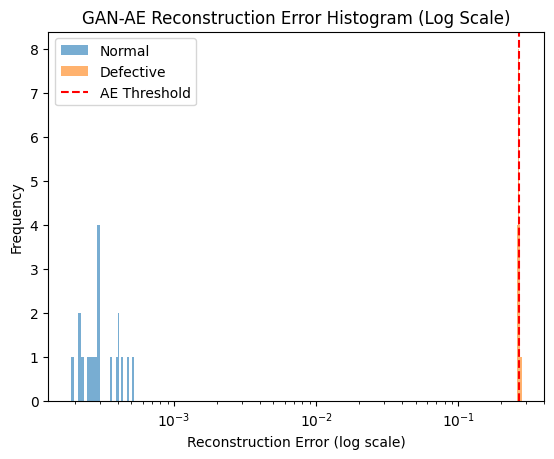

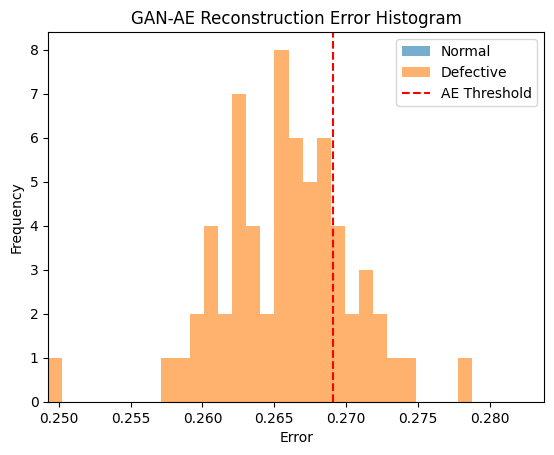

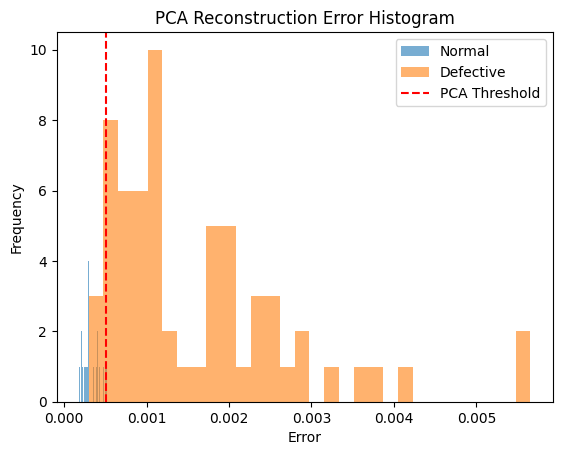

In [17]:
import matplotlib.pyplot as plt
print("GANAutoencoder threshold: ", threshold)
print("PCA threshold: ", pca_threshold)
print("Normal min:", normal_errors.min())
print("Defective min:", reconstruction_errors[true_labels==1].min())


plt.hist(normal_errors, bins=30, alpha=0.6, label="Normal")
plt.hist(reconstruction_errors[true_labels == 1], bins=30, alpha=0.6, label="Defective")
plt.axvline(threshold, color='red', linestyle='--', label="AE Threshold")

plt.xscale("log")   #  KEY FIX

plt.title("GAN-AE Reconstruction Error Histogram (Log Scale)")
plt.xlabel("Reconstruction Error (log scale)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

all_gan_errors = np.concatenate([
    normal_errors,
    reconstruction_errors[true_labels == 1]
])



plt.hist(normal_errors, bins=30, alpha=0.6, label="Normal")
plt.hist(reconstruction_errors[true_labels==1], bins=30, alpha=0.6, label="Defective")
plt.axvline(threshold, color='red', linestyle='--', label="AE Threshold")
plt.title("GAN-AE Reconstruction Error Histogram")
plt.xlabel("Error")
plt.xlim(
    reconstruction_errors.min(),
    (reconstruction_errors.max()+0.005)
)
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.hist(pca_errors[true_labels==0], bins=30, alpha=0.6, label="Normal")
plt.hist(pca_errors[true_labels==1], bins=30, alpha=0.6, label="Defective")
plt.axvline(pca_threshold, color='red', linestyle='--', label="PCA Threshold")
plt.title("PCA Reconstruction Error Histogram")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()





# =============================================================
# 18️ Top-K Anomalies Visualization with Heatmaps
# =============================================================

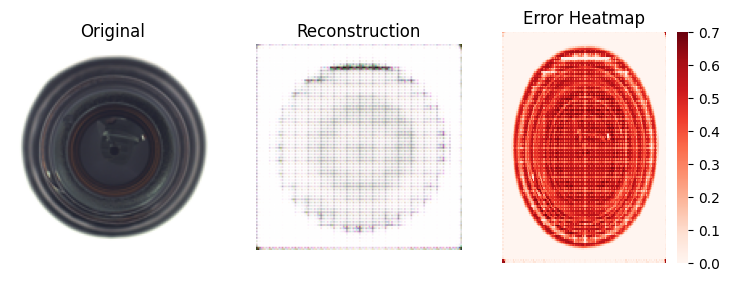

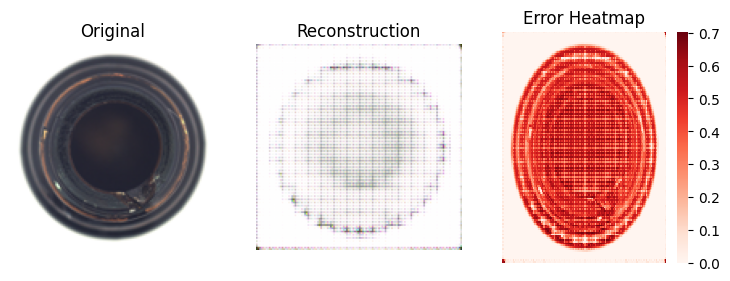

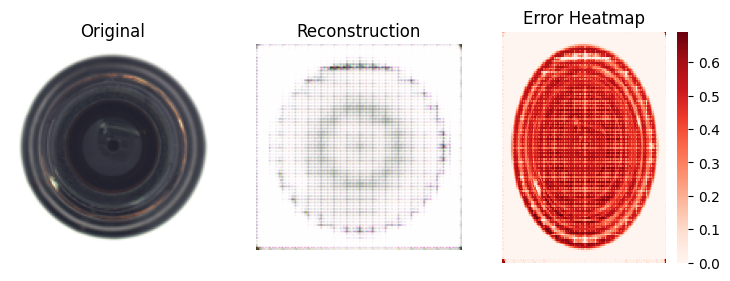

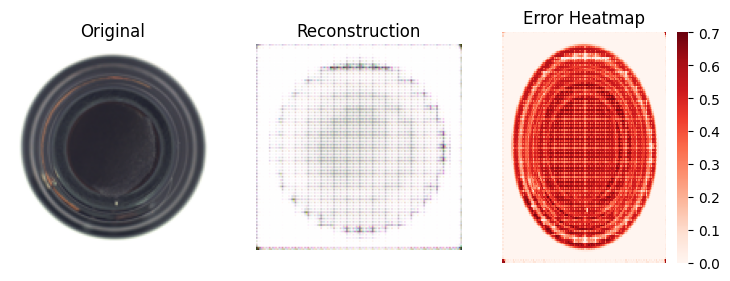

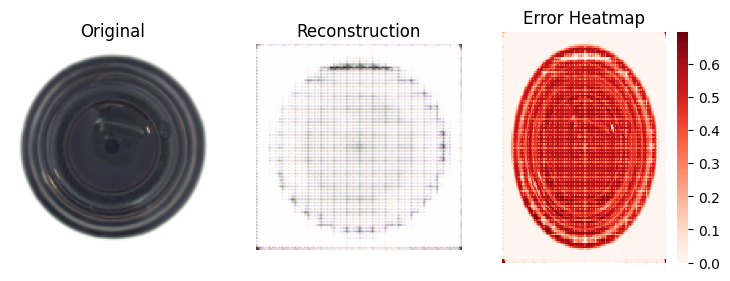

In [18]:
import seaborn as sns

# Number of most anomalous samples to visualize
K = 5

# Indices of top-K reconstruction errors
top_idx = np.argsort(reconstruction_errors)[-K:]

for idx in top_idx:
    path = image_paths_list[idx]

    # Load and preprocess image
    img = Image.open(path).convert("RGB").resize((128,128))
    img_tensor = ae_transform(img).unsqueeze(0).to(device)

    ae_model.eval()
    with torch.no_grad():
        recon = ae_model(img_tensor).cpu().squeeze().permute(1,2,0).numpy()

    # Original image
    orig = np.array(img)/255.0

    # Pixel-wise reconstruction error
    error_map = np.mean((orig - recon)**2, axis=2)

    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(recon)
    plt.title("Reconstruction")
    plt.axis('off')

    plt.subplot(1,3,3)
    sns.heatmap(error_map, cmap="Reds")
    plt.title("Error Heatmap")
    plt.axis('off')

    plt.show()